In [55]:
import em_utils.mt_simple as mt
import matplotlib.pyplot as plt
import numpy as np
import datetime
from scipy.constants import mu_0

import importlib
import json

## IRIS
[transfer functions](https://ds.iris.edu/spud/emtf)

In [56]:
mt = importlib.reload(mt)

## Tiny Town!

In [117]:
cop = mt.MTTimeChannelCollection.from_json("data/Lab5/cop24.json")

## Carter Lake

In [118]:
coo = mt.MTTimeChannelCollection.from_json("data/Lab5/coo24.json")

## Plotting channels

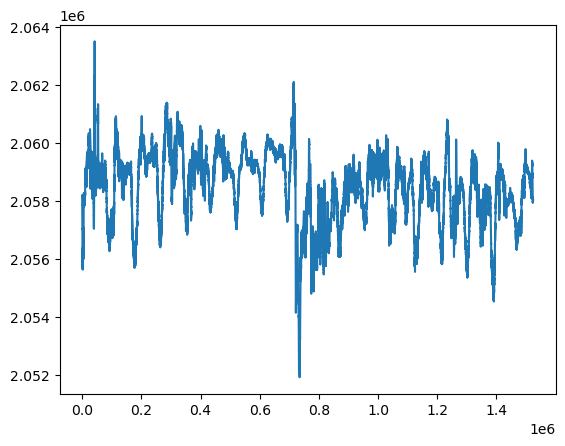

In [59]:
cop.channels[2].plot()

In [60]:
COP = cop.frequency_spectrum()

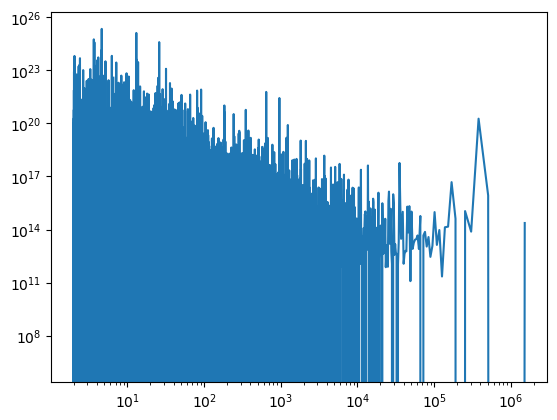

In [61]:
f, Z = COP.calculate_transfer_funcs()
rho_a = mt.calc_rho_a(f, Z)
plt.loglog(1/f, rho_a[..., 0, 1])

## Calibrating the data

In [62]:
COP = cop.frequency_spectrum().calibrate()

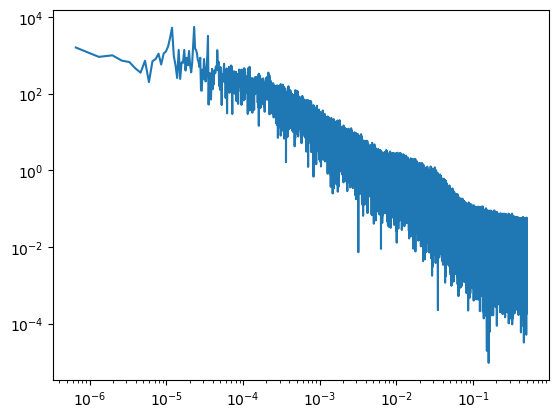

In [63]:
ch = COP.channels[3]
ch.plot()

In [64]:
f, Z = mt.calculate_Z(COP)
rho_a = mt.calc_rho_a(f, Z)

Text(0, 0.5, '$\\rho_a$ $(\\Omega m)$')

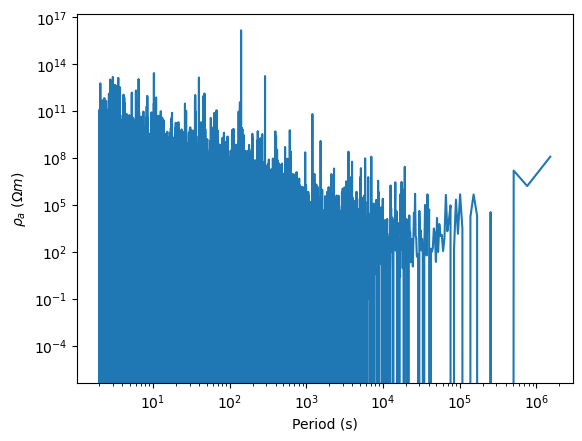

In [65]:
plt.loglog(1/f, rho_a[..., 0, 1])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")

## splitting data

In [66]:
n_splits = 50

In [67]:
cop_split = cop.split(n_splits)
COP_split = cop_split.frequency_spectrum().calibrate()

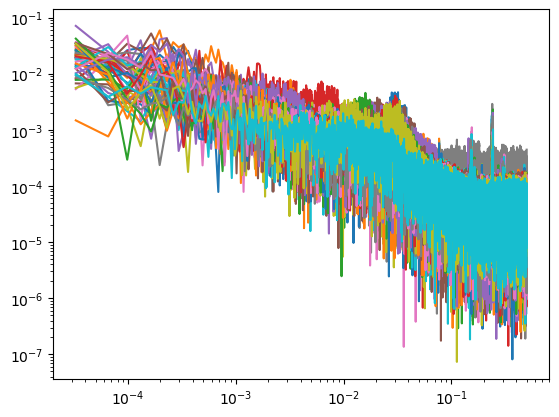

In [68]:
COP_split.channels[0].plot()

In [69]:
f, Z = mt.calculate_Z(COP_split)
rho_a = mt.calc_rho_a(f, Z)

Text(0, 0.5, '$\\rho_a$ $(\\Omega m)$')

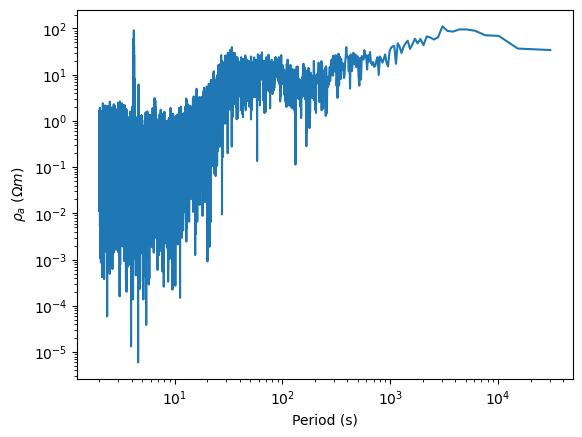

In [70]:
plt.loglog(1/f, rho_a[..., 0, 1])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")

## Windowing!

In [71]:
cop_wind = cop_split.window()
COP_wind = cop_wind.frequency_spectrum().calibrate()

In [72]:
f, Z = mt.calculate_Z(COP_wind)
rho_a = mt.calc_rho_a(f, Z)

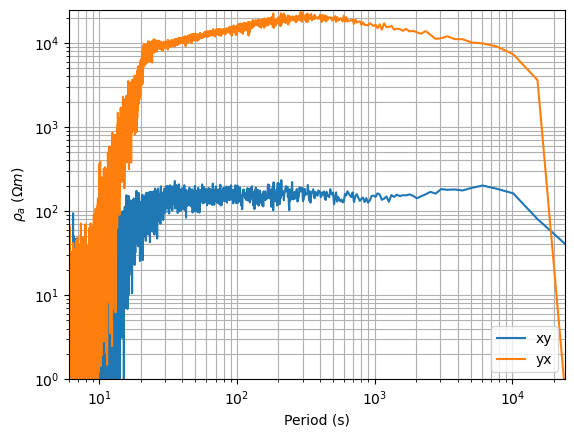

In [73]:
plt.loglog(1/f, rho_a[..., 0, 1], label='xy')
plt.loglog(1/f, rho_a[..., 1, 0], label='yx')
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

## Orienting

In [84]:
COP_orient = COP_wind.orient()

In [85]:
f, Z = mt.calculate_Z(COP_orient)
rho_a = mt.calc_rho_a(f, Z)

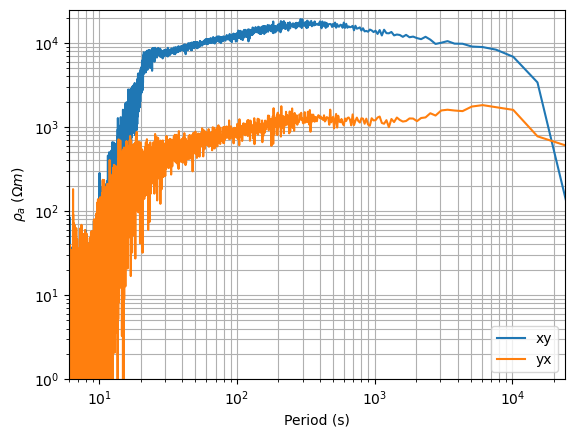

In [86]:
plt.loglog(1/f, rho_a[..., 0, 1], label='xy')
plt.loglog(1/f, rho_a[..., 1, 0], label='yx')
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

## Detrend

In [100]:
cop_detrend = cop.split(n_splits).detrend().window()
COP_detrend = cop_detrend.frequency_spectrum().calibrate().orient()

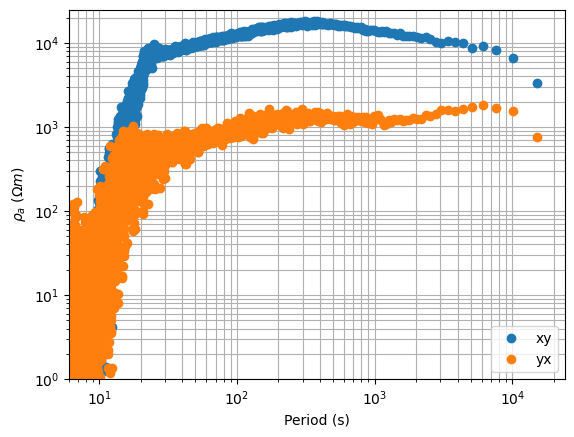

In [101]:
f, Z = mt.calculate_Z(COP_detrend)
rho_a = mt.calc_rho_a(f, Z)

plt.loglog(1/f, rho_a[..., 0, 1], label='xy', marker='o', linestyle="")
plt.loglog(1/f, rho_a[..., 1, 0], label='yx', marker='o', linestyle="")
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

## Frequency Banding

In [102]:
period_bands = np.r_[
    np.logspace(np.log10(7), np.log10(1000), 25),
    np.logspace(np.log10(1000), np.log10(20_000), 5)[1:]
]

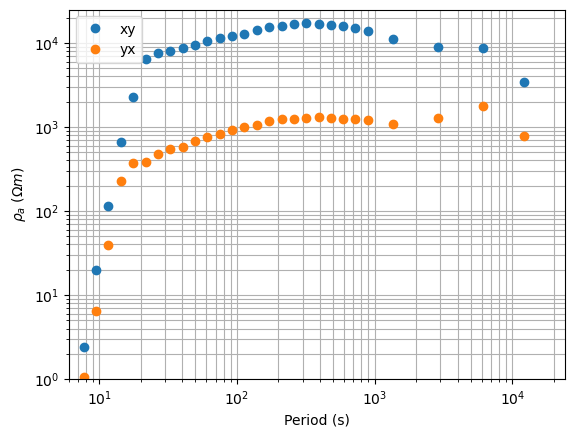

In [104]:
f, Z = mt.calculate_Z(COP_detrend, period_bands=period_bands)
rho_a = mt.calc_rho_a(f, Z)

plt.loglog(1/f, rho_a[..., 0, 1], label='xy', marker='o', linestyle="")
plt.loglog(1/f, rho_a[..., 1, 0], label='yx', marker='o', linestyle="")
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

## Remote Referencing

In [105]:
period_bands_2 = np.r_[
    np.logspace(np.log10(7), np.log10(1000), 25),
    np.logspace(np.log10(1000), np.log10(24000), 7)[1:]
]

In [106]:
cop_overlap, coo_overlap = mt.get_overlapping_series(cop, coo)

In [113]:
cop_rr = cop_overlap.split(20).detrend().window()
COP_rr = cop_rr.frequency_spectrum().calibrate().orient()

coo_rr = coo_overlap.split(20).detrend().window()
COO_rr = coo_rr.frequency_spectrum().calibrate().orient()

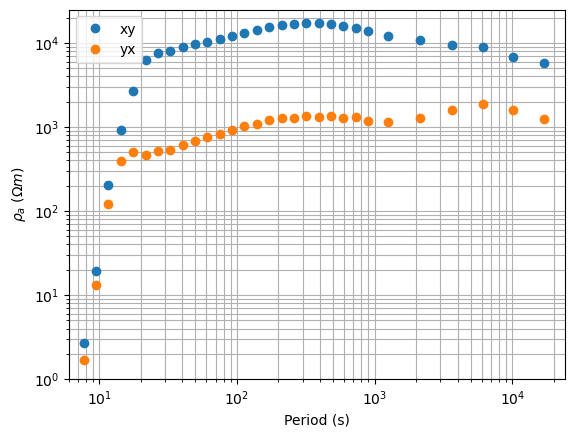

In [114]:
f, Z = mt.calculate_Z(COP_rr, remote=COO_rr, period_bands=period_bands_2)
rho_a = mt.calc_rho_a(f, Z)

plt.loglog(1/f, rho_a[..., 0, 1], label='xy', marker='o', linestyle="")
plt.loglog(1/f, rho_a[..., 1, 0], label='yx', marker='o', linestyle="")
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

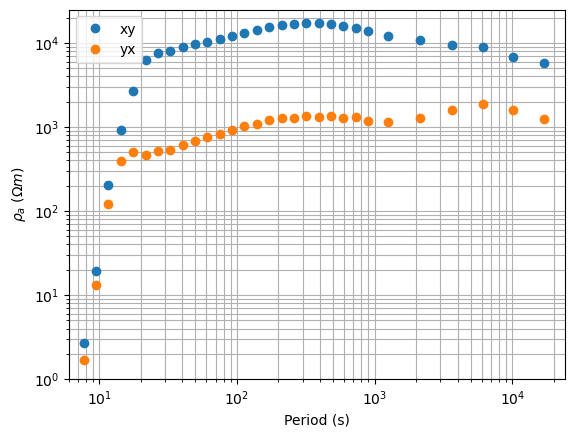

In [115]:
f, Z = mt.calculate_Z(COO_rr, remote=COP_rr, period_bands=period_bands_2)
rho_a = mt.calc_rho_a(f, Z)

plt.loglog(1/f, rho_a[..., 0, 1], label='xy', marker='o', linestyle="")
plt.loglog(1/f, rho_a[..., 1, 0], label='yx', marker='o', linestyle="")
plt.xlim([6, 24_000])
plt.ylim([1, 25_000])
plt.xlabel("Period (s)")
plt.ylabel(r"$\rho_a$ $(\Omega m)$")
plt.legend()
plt.grid(which='both')

### Todo:

* Experiment with adjusting the number of splits

* Experiment with the frequency bands

* Comment on the changes to the calculated data after each operation:

    * Calibration
    * Splitting
    * Detrending
    * Windowing
    * Rotating
    * Frequency Banding
    * Remote Referencing